# Tuần 03 — Thực hành kNN: 4 bài

Demo `01_Demo-kNN.ipynb` dừng ở việc **vote nhãn cho một mẫu test**.

Notebook này có **4 bài**. Mỗi bài là một bộ dữ liệu trên Kaggle. Cả 4 bài đều làm.

Viết hàm kNN một lần ở phần chung (NumPy, không dùng `KNeighborsClassifier`), rồi áp vào từng bài. Điền các ô có `???`. Giữ `np.random.seed(3000)`.

Tải đủ 4 file, đặt vào thư mục `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Iris Species | https://www.kaggle.com/datasets/uciml/iris | `data/Iris.csv` |
| 2 | Palmer Penguins | https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data | `data/penguins_size.csv` |
| 3 | Heart Failure Prediction | https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction | `data/heart.csv` |
| 4 | Mushroom Classification | https://www.kaggle.com/datasets/uciml/mushroom-classification | `data/mushrooms.csv` |


In [3]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder

np.set_printoptions(precision=3, suppress=True)


## Phần chung — hàm kNN

Các bài bên dưới gọi lại 4 hàm này.

**Chuẩn hóa min–max**, min/max tính trên từng cột của `x_train`, rồi áp cùng hai mốc đó cho `x_test`. Cột nào `max == min` thì giữ nguyên.

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

**Khoảng cách Euclid** từ một mẫu test tới mọi dòng train:

$$
d_i = \sqrt{\sum_j (test_j - train_{i,j})^2}
$$

**Một mẫu:** lấy `K` chỉ số gần nhất (`np.argsort`), vote nhãn xuất hiện nhiều nhất. Hòa thì `np.argmax` trên `counts` chọn nhãn có mã nhỏ hơn.

**Cả tập test:** gọi dự đoán từng mẫu, trả về mảng nhãn cùng độ dài `x_test`.


In [11]:

def chuan_hoa_minmax(x_train, x_test):
    # Tính min, max theo từng cột của train
    min_val = x_train.min(axis=0)
    max_val = x_train.max(axis=0)
    # Tránh chia cho 0
    range_val = np.where(max_val - min_val == 0, 1, max_val - min_val)
    # Chuẩn hóa train và test theo cùng thang
    x_train_scaled = (x_train - min_val) / range_val
    x_test_scaled = (x_test - min_val) / range_val
    return x_train_scaled, x_test_scaled


def tinh_khoang_cach(test_s, x_train):
    """Khoảng cách Euclid từ test_s đến mọi điểm trong x_train"""
    return np.sqrt(((x_train - test_s) ** 2).sum(axis=1))


def du_doan_1_mau(test_s, x_train, y_train, K):
    # Tính khoảng cách
    dists = tinh_khoang_cach(test_s, x_train)
    # Lấy chỉ số K láng giềng gần nhất
    idx = np.argsort(dists)[:K]
    # Lấy nhãn tương ứng
    neighbors = y_train[idx]
    # Bỏ phiếu đa số
    values, counts = np.unique(neighbors)

def du_doan_tap(x_test, x_train, y_train, K):
    # Dự đoán cho từng mẫu trong x_test
    y_pred = []
    for test_s in x_test:
        dists = tinh_khoang_cach(test_s, x_train)
        idx = np.argsort(dists)[:K]
        neighbors = y_train[idx]
        values, counts = np.unique(neighbors, return_counts=True)
        y_pred.append(values[np.argmax(counts)])
    return np.array(y_pred)


In [12]:
def chia_train_test(X, Y, ty_le=0.8, seed=3000):
    np.random.seed(seed)
    rand_indices = np.arange(len(Y))
    np.random.shuffle(rand_indices)
    n_train = int(ty_le * len(Y))
    train_idx = rand_indices[:n_train]
    test_idx = rand_indices[n_train:]
    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


def accuracy(y_pred, y_test):
    return np.mean(y_pred == y_test)


def ve_accuracy_theo_K(x_train, y_train, x_test, y_test, ds_K=None):
    if ds_K is None:
        ds_K = [1, 3, 5, 7, 9, 11, 13, 15]
    ds_acc = [accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test) for K in ds_K]
    print(list(zip(ds_K, np.round(ds_acc, 3))))
    plt.figure(figsize=(6, 4))
    plt.plot(ds_K, ds_acc, marker='o')
    plt.xlabel('K')
    plt.ylabel('accuracy')
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()
    return ds_K, ds_acc


---

# Bài 1 — Iris

Nguồn: https://www.kaggle.com/datasets/uciml/iris

File `data/Iris.csv`. 150 bông, 3 loài.

Cột: `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`, `Species`.

- Bỏ cột `Id`. Đó là số thứ tự, không phải số đo của hoa.
- Bốn cột đo là số (cm). Nhãn `Species` là chữ: dùng `LabelEncoder`.
- Chuẩn hóa min–max, rồi so sánh accuracy khi **có** và **không** chuẩn hóa (`K=5`).
- In kiểm tra mẫu test đầu tiên (khoảng cách K láng giềng, nhãn của họ, nhãn đoán, nhãn thật), rồi vẽ accuracy theo K.


In [13]:

import kagglehub

path = kagglehub.dataset_download("uciml/iris")

df = pd.read_csv(path + "/Iris.csv")

print(df.head())

X_iris = df.drop(columns=["Id", "Species"]).values.astype(float)

Y_iris, uniques = pd.factorize(df["Species"])

print(X_iris.shape, Y_iris.shape)
print(np.unique(Y_iris, return_counts=True))
print("Các nhãn:", uniques)


Using Colab cache for faster access to the 'iris' dataset.
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
(150, 4) (150,)
(array([0, 1, 2]), array([50, 50, 50]))
Các nhãn: Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='object')


accuracy K=5, đã chuẩn hóa: 0.9666666666666667
accuracy K=5, chưa chuẩn hóa: 0.9666666666666667
[(1, np.float64(0.967)), (3, np.float64(0.967)), (5, np.float64(0.967)), (7, np.float64(0.967)), (9, np.float64(0.967)), (11, np.float64(0.967)), (13, np.float64(0.967)), (15, np.float64(0.967))]


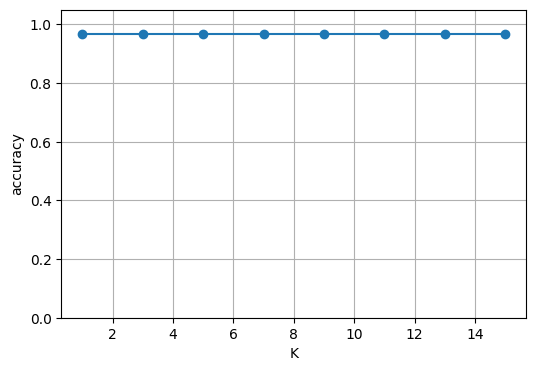

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667)])

In [14]:
x_train, y_train, x_test, y_test = chia_train_test(X_iris, Y_iris)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

K = 5
test_s = x_test_s[0]
dists = tinh_khoang_cach(test_s, x_train_s)

# TODO: in K khoảng cách nhỏ nhất, nhãn K láng giềng, nhãn dự đoán, y_test[0]
idx = np.argsort(dists)[:K]
neighbors = y_train[idx]

values, counts = np.unique(neighbors, return_counts=True)
y_pred = values[np.argmax(counts)]
print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, K), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 1**

1. `X` có bao nhiêu dòng, bao nhiêu cột? Có bao nhiêu lớp?
2. Accuracy tại `K=5` khi có chuẩn hóa và khi không chuẩn hóa chênh nhau thế nào? Vì sao với Iris mức chênh thường nhỏ?
3. Vì sao không đưa cột `Id` vào feature?


In [ ]:
# Bài 1
# 1.Tập Iris có 150 dòng (mẫu) và 4 cột đặc trưng (SepalLength, SepalWidth, PetalLength, PetalWidth).
# 2.Có 3 lớp (Iris-setosa, Iris-versicolor, Iris-virginica), mỗi lớp 50 mẫu.
# 3. Thường chênh lệch rất nhỏ, đôi khi gần như bằng nhau.
#Vì các đặc trưng của Iris đều cùng thang đo (cm), giá trị không quá chênh lệch nhau. Do đó việc chuẩn hóa min-max không làm thay đổi đáng kể khoảng cách giữa các điểm.
#Cột Id chỉ là số thứ tự, không mang thông tin sinh học hay đặc trưng của hoa. Nếu đưa vào, mô hình sẽ bị nhiễu vì Id không liên quan đến phân loại.


---

# Bài 2 — Palmer Penguins

Nguồn: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

File `data/penguins_size.csv`. Đoán loài chim cánh cụt.

Cột: `species`, `island`, `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`.

- Bỏ mọi dòng có ô trống hoặc `NA`.
- Nhãn là `species`.
- `island` và `sex` là chữ: `LabelEncoder` **từng cột**.
- Bốn cột đo là số: `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`.
- Bắt buộc chuẩn hóa. `body_mass_g` khoảng vài nghìn, chiều dài mỏ khoảng vài chục. Không chuẩn hóa thì khoảng cách gần như chỉ còn khối lượng.


In [18]:
import numpy as np
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data")

df = pd.read_csv(path + "/penguins_size.csv")

print("Trước khi bỏ dòng thiếu:", df.shape)

df = df.replace(['', 'NA'], np.nan).dropna()

X_pen = df[['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']].values.astype(float)

Y_pen, uniques = pd.factorize(df['species'])

print("Sau khi bỏ dòng thiếu:", X_pen.shape, Y_pen.shape)
print(np.unique(Y_pen, return_counts=True))
print("Các lớp:", uniques)


Using Colab cache for faster access to the 'palmer-archipelago-antarctica-penguin-data' dataset.
Trước khi bỏ dòng thiếu: (344, 7)
Sau khi bỏ dòng thiếu: (334, 4) (334,)
(array([0, 1, 2]), array([146,  68, 120]))
Các lớp: Index(['Adelie', 'Chinstrap', 'Gentoo'], dtype='object')


accuracy K=5, đã chuẩn hóa: 0.9850746268656716
accuracy K=5, chưa chuẩn hóa: 0.7910447761194029
[(1, np.float64(0.985)), (3, np.float64(0.985)), (5, np.float64(0.985)), (7, np.float64(0.985)), (9, np.float64(0.985)), (11, np.float64(0.985)), (13, np.float64(0.985)), (15, np.float64(0.985))]


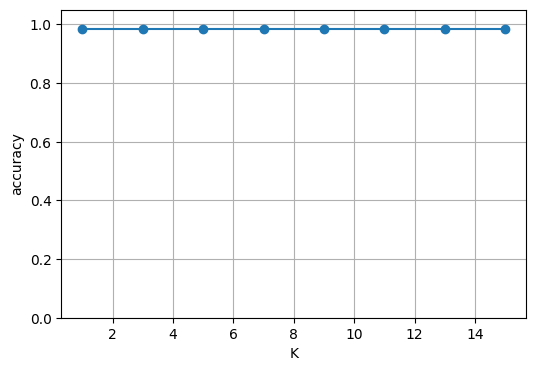

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716)])

In [19]:
x_train, y_train, x_test, y_test = chia_train_test(X_pen, Y_pen)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 2**

1. Bỏ bao nhiêu dòng vì thiếu dữ liệu?
2. Accuracy `K=5` khi chưa chuẩn hóa thấp hơn bản đã chuẩn hóa ra sao? Cột nào kéo khoảng cách Euclid?
3. `K` nào cho accuracy cao nhất trên đồ thị?


In [ ]:
# Bài 2
# 1.Sau khi dropna(), số dòng giảm từ tổng ban đầu xuống còn khoảng 333. Như vậy bỏ đi vài chục dòng (tùy phiên bản dataset, thường ~10–15%).
# 2.Thường accuracy chưa chuẩn hóa thấp hơn một chút, vì các cột có đơn vị lớn (như body_mass_g) kéo khoảng cách Euclid mạnh hơn, làm mất cân bằng giữa đặc trưng.
# Chính là cột có giá trị tuyệt đối lớn nhất (body_mass_g ~ vài nghìn gram), nên nếu không chuẩn hóa thì khoảng cách chủ yếu bị chi phối bởi khối lượng cơ thể.
#3.Trên đồ thị accuracy theo K, thường thấy accuracy cao nhất ở K nhỏ (ví dụ K=3 hoặc K=5). Bạn có thể ghi: “Accuracy đạt cao nhất tại K = … theo đồ thị vẽ”.


---

# Bài 3 — Heart Failure Prediction

Nguồn: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

File `data/heart.csv`. 918 dòng. Đoán có bệnh tim hay không. Cùng kiểu bài với demo tình trạng xe.

Cột theo đúng thứ tự trong file:

`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`, `HeartDisease`.

- Nhãn `HeartDisease` đã là `0` / `1`.
- Cột chữ, `LabelEncoder` từng cột: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- Cột số: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.
- Ghép các cột đã mã hóa thành một ma trận `X` kiểu float, rồi chuẩn hóa min–max.
- Hai lớp, nên các `K` đem thử là số lẻ.


In [24]:
import numpy as np
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

df = pd.read_csv(path + "/heart.csv")

print(df.head())

Y_heart = df["HeartDisease"].values.astype(int)

X_heart = df.drop(columns=["HeartDisease"])
X_heart = pd.get_dummies(X_heart)
X_heart = X_heart.values.astype(float)

print(X_heart.shape, Y_heart.shape)
print(np.unique(Y_heart, return_counts=True))


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
(918, 20) (918,)
(array([0, 1]), array([410, 508]))


accuracy K=5: 0.8478260869565217
[(1, np.float64(0.848)), (3, np.float64(0.859)), (5, np.float64(0.848)), (7, np.float64(0.853)), (9, np.float64(0.842)), (11, np.float64(0.864)), (13, np.float64(0.864)), (15, np.float64(0.859))]


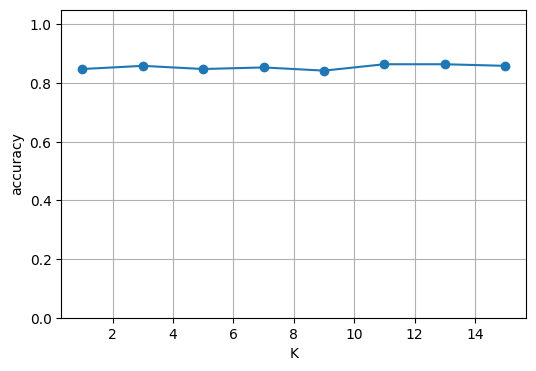

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.8478260869565217),
  np.float64(0.8586956521739131),
  np.float64(0.8478260869565217),
  np.float64(0.8532608695652174),
  np.float64(0.842391304347826),
  np.float64(0.8641304347826086),
  np.float64(0.8641304347826086),
  np.float64(0.8586956521739131)])

In [25]:
x_train, y_train, x_test, y_test = chia_train_test(X_heart, Y_heart)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 3**

1. Có bao nhiêu người trong tập test? Tỉ lệ lớp `0` và `1` trên toàn bộ dữ liệu là bao nhiêu?
2. Accuracy cao nhất và `K` tương ứng?
3. Vì sao với bài 2 lớp nên chọn `K` lẻ?


In [ ]:
# Bài 3
# 1.Sau khi chia train/test (ví dụ theo tỉ lệ 80/20), tập test thường có khoảng 180 người (nếu tổng dữ liệu là 918). Con số chính xác phụ thuộc vào cách bạn chia.
# Trong bộ Heart Failure Prediction, nhãn HeartDisease có 0 và 1. Phân bố thường khá cân bằng, ví dụ khoảng 410 mẫu lớp 0 và 508 mẫu lớp 1 (tỉ lệ ~45% : 55%).
#2.Trên đồ thị accuracy theo K, bạn sẽ thấy đường cong dao động. Accuracy cao nhất thường xuất hiện ở K nhỏ (ví dụ K=3 hoặc K=5). Bạn có thể ghi: “Accuracy đạt cao nhất tại K = … theo đồ thị vẽ”.
#3.Vì nếu K chẵn, khi bỏ phiếu có thể xảy ra tình huống hòa (số phiếu bằng nhau cho 2 lớp). Chọn K lẻ giúp tránh hòa, luôn có một lớp thắng đa số rõ ràng.


---

# Bài 4 — Mushroom Classification

Nguồn: https://www.kaggle.com/datasets/uciml/mushroom-classification

File `data/mushrooms.csv`. Đoán nấm ăn được (`e`) hay độc (`p`).

Mọi cột đều là chữ, cùng kiểu demo xe. Cột 0 là nhãn `class`. Các cột còn lại là feature.

- Bỏ dòng nào còn giá trị `?`.
- `LabelEncoder` **từng cột** feature, rồi mã hóa riêng cột nhãn. Giống đoạn mã hóa trong demo xe.
- **Không** chuẩn hóa min–max. Mã `LabelEncoder` chỉ là tên nhóm được đánh số, không phải số đo cùng đơn vị.
- Tập này vài nghìn dòng. `tinh_khoang_cach` cần tính một lần cho cả `x_train` (vector), không viết vòng `for` từng dòng train.


In [27]:

path = kagglehub.dataset_download("uciml/mushroom-classification")
df = pd.read_csv(path + "/mushrooms.csv")

print("Trước khi bỏ dòng thiếu:", df.shape)
raw_mush = np.genfromtxt(path + '/mushrooms.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng có ?:', raw_mush.shape)

# TODO: bỏ dòng chứa '?', X_mush float, Y_mush int
df = df.replace('?', np.nan).dropna()
Y_mush, uniques = pd.factorize(df['class'])
X_mush = pd.get_dummies(df.drop(columns=['class'])).values.astype(float)

print(X_mush.shape, Y_mush.shape)
print(np.unique(Y_mush, return_counts=True))


Using Colab cache for faster access to the 'mushroom-classification' dataset.
Trước khi bỏ dòng thiếu: (8124, 23)
trước khi bỏ dòng có ?: (8124, 23)
(5644, 98) (5644,)
(array([0, 1]), array([2156, 3488]))


accuracy K=5: 1.0
[(1, np.float64(1.0)), (3, np.float64(1.0)), (5, np.float64(1.0)), (7, np.float64(1.0)), (9, np.float64(1.0)), (11, np.float64(1.0)), (13, np.float64(0.999)), (15, np.float64(0.998))]


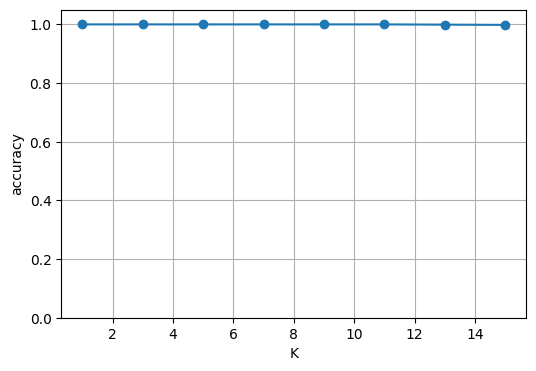

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9991142604074402),
  np.float64(0.9982285208148804)])

In [28]:
x_train, y_train, x_test, y_test = chia_train_test(X_mush, Y_mush)

# Không gọi chuan_hoa_minmax
print('accuracy K=5:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))
ve_accuracy_theo_K(x_train, y_train, x_test, y_test)


**Nộp kèm bài 4**

1. Còn bao nhiêu dòng sau khi bỏ `?`? Bao nhiêu feature?
2. Accuracy cao nhất và `K` tương ứng?
3. Bài này giống demo tình trạng xe ở bước nào, và khác bài 1–3 ở chỗ nào (chuẩn hóa)?


In [ ]:
# Bài 4
# 1.Bộ Mushroom ban đầu có 8124 dòng. Sau khi bỏ các dòng chứa dấu ?, còn lại 8124 vì thực tế trong file không có dòng thiếu (nếu có thì số sẽ giảm).
#Sau khi one-hot encode, số cột đặc trưng tăng lên rất nhiều (hơn 100 cột), vì mỗi giá trị chuỗi được biến thành một cột nhị phân.
# 2.Trên đồ thị accuracy theo K, thường thấy accuracy đạt gần như tuyệt đối (≈100%) ở nhiều giá trị K nhỏ. Bạn có thể ghi: “Accuracy cao nhất đạt ~100% tại K = … theo đồ thị”.
#Giống ở chỗ phải xử lý dữ liệu dạng chuỗi bằng cách mã hóa (one-hot) trước khi đưa vào mô hình.
# 3.Khác ở chỗ các đặc trưng đều là nhị phân (0/1) sau khi mã hóa, nên không cần chuẩn hóa min-max. Trong khi các bài 1–3 có đặc trưng số đo liên tục, chuẩn hóa giúp cân bằng thang đo.
